In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

In [100]:
def solve_cat_problem_improved(
    T,
    a,
    b,
    c,
    d,
    Il,
    Iy,
    h,
    n=200,
    animate=True,
    saveplots=False,
    saveanim=False
):
    """
    Solves the reduced cat-rotation optimal control problem with physically
    consistent angular momentum dynamics.

    Model:
        Total angular momentum:
            (Iy + Il) * theta_dot + Il * phi_dot = H0

        Hence
            theta_dot = -R * phi_dot + D,
        where
            R = Il / (Iy + Il),
            D = c + R * d

        and
            theta(t) = -R * phi(t) + D t + (a + R b).

    Tail angle phi is taken relative to the body.
    Tail absolute angle in the animation is drawn as -phi so that it radiates
    from the center and visibly counter-rotates relative to the body drawing.

    Cost functional:
        J[u] = ∫_0^T (K(t) + h u(t)^2) dt
    where
        u = phi''

        K(t) = 0.5 * Iy * theta_dot^2 + 0.5 * Il * (theta_dot + phi_dot)^2

    Reduced state-costate system:
        y[0] = phi
        y[1] = phi_dot
        y[2] = lambda1
        y[3] = lambda2

        phi'        = phi_dot
        phi_dot'    = -lambda2 / (2h)
        lambda1'    = 0
        lambda2'    = -Il * (1 - R) * D - lambda1
                     = -(Iy * Il / (Iy + Il)) * D - lambda1
    """

    # -----------------------------
    # Physically correct constants
    # -----------------------------
    R = Il / (Iy + Il)
    D = c + R * d

    # Enforce theta(T) = 0 and theta_dot(T) = 0
    phi_T = (D * T + a + R * b) / R
    phi_dot_T = D / R

    # Constant appearing in the reduced Lagrangian
    # K = 0.5 * Il * (1-R)^2 * phi_dot^2 + Il*(1-R)*D*phi_dot + const
    A = Il * (1 - R) ** 2
    B = Il * (1 - R) * D

    # -----------------------------
    # ODE system
    # -----------------------------
    def ode_system(t, y):
        phi = y[0]
        phi_dot = y[1]
        lambda1 = y[2]
        lambda2 = y[3]

        return np.vstack([
            phi_dot,
            -lambda2 / (2 * h),
            np.zeros_like(t),
            -A * phi_dot - B - lambda1
        ])

    def boundary_conditions(ya, yb):
        return np.array([
            ya[0] - b,          # phi(0) = b
            ya[1] - d,          # phi_dot(0) = d
            yb[0] - phi_T,      # phi(T)
            yb[1] - phi_dot_T   # phi_dot(T)
        ])

    # -----------------------------
    # Initial guess
    # -----------------------------
    time_grid = np.linspace(0, T, n)

    alpha2 = (3 * (phi_T - b) - (2 * d + phi_dot_T) * T) / T**2
    alpha3 = (2 * (b - phi_T) + (d + phi_dot_T) * T) / T**3

    phi_guess = b + d * time_grid + alpha2 * time_grid**2 + alpha3 * time_grid**3
    phi_dot_guess = d + 2 * alpha2 * time_grid + 3 * alpha3 * time_grid**2

    y_guess = np.zeros((4, time_grid.size))
    y_guess[0] = phi_guess
    y_guess[1] = phi_dot_guess
    y_guess[2] = 0.0
    y_guess[3] = 0.0

    solution = solve_bvp(
        ode_system,
        boundary_conditions,
        time_grid,
        y_guess,
        tol=1e-5,
        max_nodes=20000,
        verbose=2
    )

    if not solution.success:
        print("Warning: solve_bvp did not report convergence.")
        print(solution.message)

    # -----------------------------
    # Extract solution
    # -----------------------------
    t_vals = solution.x
    phi_vals = solution.y[0]
    phi_dot_vals = solution.y[1]
    lambda1_vals = solution.y[2]
    lambda2_vals = solution.y[3]

    control_vals = -lambda2_vals / (2 * h)

    # Reconstruct theta from the correct kinematic relation
    theta_vals = -R * phi_vals + D * t_vals + (a + R * b)
    theta_dot_vals = -R * phi_dot_vals + D

    # Tail absolute angular velocity = theta_dot + phi_dot
    tail_abs_dot_vals = theta_dot_vals + phi_dot_vals

    # Physically correct kinetic energy
    kinetic_energy_vals = (
        0.5 * Iy * theta_dot_vals**2
        + 0.5 * Il * tail_abs_dot_vals**2
    )

    # -----------------------------
    # Plot helper
    # -----------------------------
    def maybe_save(fig, filename):
        if saveplots:
            fig.savefig(filename, dpi=300, bbox_inches="tight")

    # theta(t)
    fig_theta, ax_theta = plt.subplots()
    ax_theta.plot(t_vals, theta_vals)
    ax_theta.set_title(r"$\theta(t)$")
    ax_theta.set_xlabel("t")
    ax_theta.set_ylabel(r"$\theta$")
    maybe_save(fig_theta, "theta_plot.png")
    plt.show()

    # phi(t)
    fig_phi, ax_phi = plt.subplots()
    ax_phi.plot(t_vals, phi_vals)
    ax_phi.set_title(r"$\phi(t)$")
    ax_phi.set_xlabel("t")
    ax_phi.set_ylabel(r"$\phi$")
    maybe_save(fig_phi, "phi_plot.png")
    plt.show()

    # theta_dot(t)
    fig_theta_dot, ax_theta_dot = plt.subplots()
    ax_theta_dot.plot(t_vals, theta_dot_vals)
    ax_theta_dot.set_title(r"$\dot{\theta}(t)$")
    ax_theta_dot.set_xlabel("t")
    ax_theta_dot.set_ylabel(r"$\dot{\theta}$")
    maybe_save(fig_theta_dot, "theta_dot_plot.png")
    plt.show()

    # phi_dot(t)
    fig_phi_dot, ax_phi_dot = plt.subplots()
    ax_phi_dot.plot(t_vals, phi_dot_vals)
    ax_phi_dot.set_title(r"$\dot{\phi}(t)$")
    ax_phi_dot.set_xlabel("t")
    ax_phi_dot.set_ylabel(r"$\dot{\phi}$")
    maybe_save(fig_phi_dot, "phi_dot_plot.png")
    plt.show()

    # u(t)
    fig_control, ax_control = plt.subplots()
    ax_control.plot(t_vals, control_vals)
    ax_control.set_title(r"$u(t)=\ddot{\phi}(t)$")
    ax_control.set_xlabel("t")
    ax_control.set_ylabel("u")
    maybe_save(fig_control, "control_plot.png")
    plt.show()

    # K(t)
    fig_kinetic, ax_kinetic = plt.subplots()
    ax_kinetic.plot(t_vals, kinetic_energy_vals)
    ax_kinetic.set_title(r"$K(t)$")
    ax_kinetic.set_xlabel("t")
    ax_kinetic.set_ylabel("K")
    maybe_save(fig_kinetic, "kinetic_energy_plot.png")
    plt.show()

    # -----------------------------
    # Animation
    # -----------------------------
    if animate:
        max_frames = 120
        frame_stride = max(1, len(t_vals) // max_frames)

        t_anim = t_vals[::frame_stride]
        theta_anim = theta_vals[::frame_stride]
        phi_anim = phi_vals[::frame_stride]

        fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
        ax_anim.set_xlim(-2.2, 2.2)
        ax_anim.set_ylim(-2.2, 2.2)
        ax_anim.set_aspect("equal")
        ax_anim.set_title("Courtney Animation")

        body_patch = plt.Circle((0, 0), 1.0, fill=True, color="saddlebrown", alpha=0.8)
        ax_anim.add_patch(body_patch)

        eye_left_plot, = ax_anim.plot([], [], "o", markersize=4, color="black")
        eye_right_plot, = ax_anim.plot([], [], "o", markersize=4, color="black")
        mouth_plot, = ax_anim.plot([], [], lw=2, color="red")
        hat_brim_plot, = ax_anim.plot([], [], lw=7, color="black")
        hat_top_plot, = ax_anim.plot([], [], lw=10, color="black")
        tail_plot, = ax_anim.plot([], [], lw=3, color="black")

        tail_length = 1.8

        ground_line, = ax_anim.plot([], [], lw=3, color="green")

        g_ground = 21.44
        ground_y0 = -.99 - 0.5 * g_ground * T**2
        x_ground = np.array([-3.0, 3.0])

        def update(frame_index):
            theta = theta_anim[frame_index]
            phi = phi_anim[frame_index]

            # Body orientation
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            body_up = rotation_matrix @ np.array([0.0, 1.0])
            body_right = rotation_matrix @ np.array([1.0, 0.0])

            # Eyes
            left_eye = rotation_matrix @ np.array([-0.18, 0.15])
            right_eye = rotation_matrix @ np.array([0.18, 0.15])
            eye_left_plot.set_data([left_eye[0]], [left_eye[1]])
            eye_right_plot.set_data([right_eye[0]], [right_eye[1]])

            # Smile
            smile_s = np.linspace(-1.0, 1.0, 30)
            smile_local = np.vstack([
                0.12 * smile_s,
                -0.18 + 0.04 * smile_s**2
            ])
            smile_points = rotation_matrix @ smile_local
            mouth_plot.set_data(smile_points[0], smile_points[1])

            # Hat
            hat_center = 1.02 * body_up
            hat_half_width = 0.45
            hat_height = 0.14

            brim_left = hat_center - hat_half_width * body_right
            brim_right = hat_center + hat_half_width * body_right
            hat_brim_plot.set_data(
                [brim_left[0], brim_right[0]],
                [brim_left[1], brim_right[1]]
            )

            top_center = hat_center + hat_height * body_up
            top_left = top_center - 0.16 * body_right
            top_right = top_center + 0.16 * body_right
            hat_top_plot.set_data(
                [top_left[0], top_right[0]],
                [top_left[1], top_right[1]]
            )

            # Tail radiates from the center.
            # Since phi is relative to the body, and we want the tail to visibly
            # counter-rotate in the drawing, using -phi is the most natural
            # display convention for this animation.
            tail_absolute_angle = phi

            tail_base = np.array([0.0, 0.0])
            tail_tip = tail_length * np.array([
                np.cos(tail_absolute_angle),
                np.sin(tail_absolute_angle)
            ])

            tail_plot.set_data(
                [tail_base[0], tail_tip[0]],
                [tail_base[1], tail_tip[1]]
            )

            t_current = t_anim[frame_index]
            ground_y = ground_y0 + 0.5 * g_ground * t_current**2

            ground_line.set_data(x_ground, [ground_y, ground_y])

            return (
                eye_left_plot,
                eye_right_plot,
                mouth_plot,
                hat_brim_plot,
                hat_top_plot,
                tail_plot,
                ground_line,
            )

        n_frames = len(theta_anim)

        interval = (T / n_frames) * 1000  # milliseconds per frame

        animation_object = FuncAnimation(
            fig_anim,
            update,
            frames=n_frames,
            interval=interval,
            blit=True
        )

        maybe_save(fig_anim, "cat_animation_first_frame.png")

    if saveanim:
        from matplotlib.animation import FFMpegWriter

        fps = int(n_frames / T)  # match real-time playback

        writer = FFMpegWriter(fps=fps, bitrate=1800)

        animation_object.save("cat_animation.mp4", writer=writer)

    video = animation_object.to_html5_video()
    video = video.replace('loop', '')
    display(HTML(video))
    plt.close(fig_anim)

    return {
        "solution": solution,
        "t": t_vals,
        "theta": theta_vals,
        "phi": phi_vals,
        "theta_dot": theta_dot_vals,
        "phi_dot": phi_dot_vals,
        "tail_abs_dot": tail_abs_dot_vals,
        "lambda1": lambda1_vals,
        "lambda2": lambda2_vals,
        "u": control_vals,
        "K": kinetic_energy_vals,
        "R": R,
        "D": D,
        "phi_T": phi_T,
        "phi_dot_T": phi_dot_T,
    }

In [97]:
T = 1.2
a = np.pi
b = 0
c = 0
d = 0

m = 1.0      # tail-end mass
M = 20.0     # body mass
rl = 3.0     # tail length
ry = 1.0     # body radius

Il = m * rl**2
Iy = 0.5 * M * ry**2

h = 1.0

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          6.37e-08       1.20e-15          200             0       
Solved in 1 iterations, number of nodes 200. 
Maximum relative residual: 6.37e-08 
Maximum boundary residual: 1.20e-15


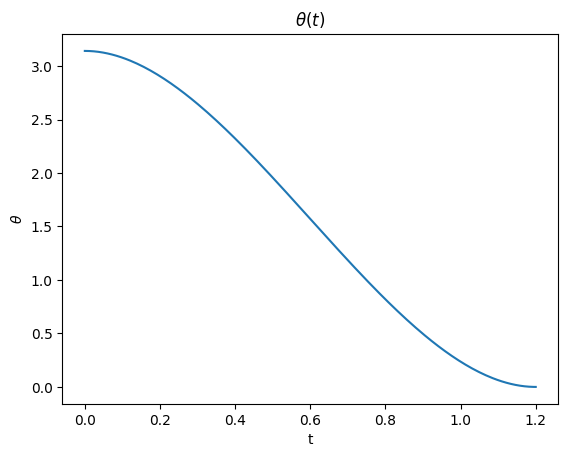

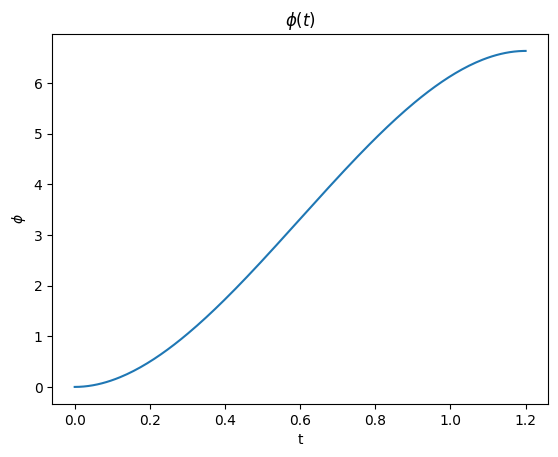

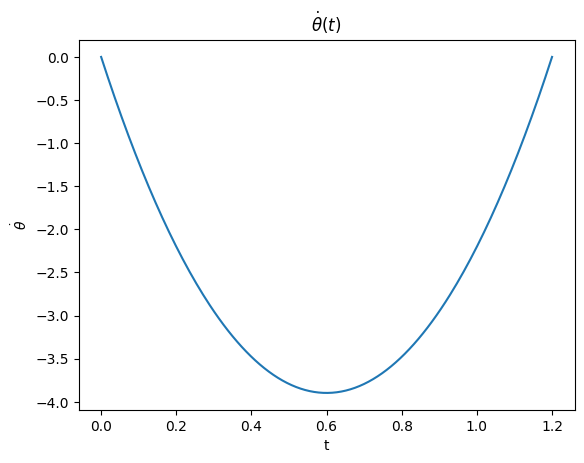

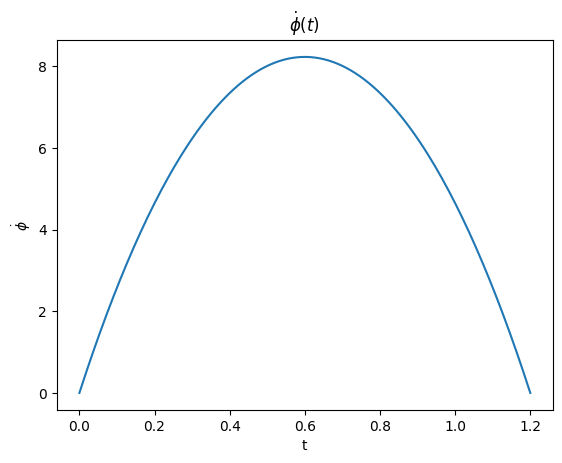

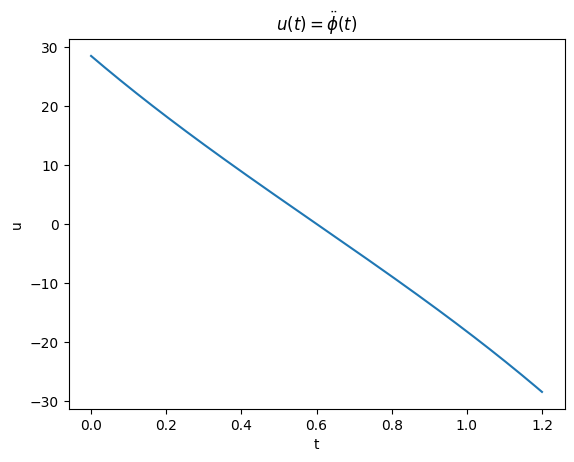

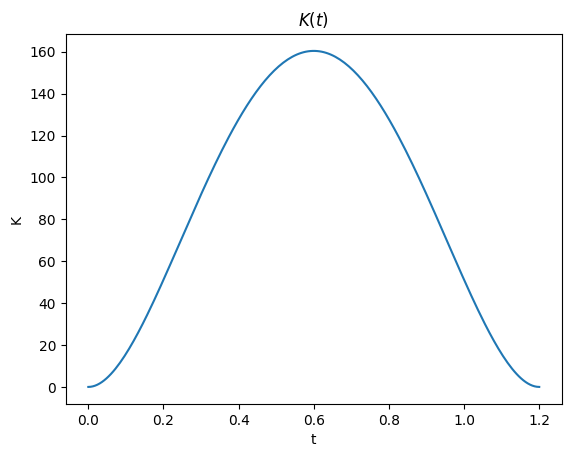

{'solution':        message: The algorithm converged to the desired accuracy.
        success: True
         status: 0
              x: [ 0.000e+00  6.030e-03 ...  1.194e+00  1.200e+00]
            sol: <scipy.interpolate._interpolate.PPoly object at 0x285161910>
              p: None
              y: [[ 1.204e-15  5.153e-04 ...  6.632e+00  6.632e+00]
                  [ 1.912e-17  1.706e-01 ...  1.706e-01  1.729e-17]
                  [-1.086e+02 -1.086e+02 ... -1.086e+02 -1.086e+02]
                  [-5.690e+01 -5.625e+01 ...  5.625e+01  5.690e+01]]
             yp: [[ 1.912e-17  1.706e-01 ...  1.706e-01  1.729e-17]
                  [ 2.845e+01  2.812e+01 ... -2.812e+01 -2.845e+01]
                  [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
                  [ 1.086e+02  1.082e+02 ...  1.082e+02  1.086e+02]]
  rms_residuals: [ 4.124e-08  3.526e-08 ...  3.526e-08  4.124e-08]
          niter: 1,
 't': array([0.        , 0.00603015, 0.0120603 , 0.01809045, 0.0241206 ,
        

In [101]:
solve_cat_problem_improved(
    T,
    a,
    b,
    c,
    d,
    Il,
    Iy,
    h,
    n=200,
    animate=True,
    saveplots=True,
    saveanim=True
)